## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange: 

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

## Import Statements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## Data Exploration

In [2]:
df = pd.read_csv('QueryResults.csv', names=['DATE', 'TAG', 'POSTS'], header=0)
df.head()

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,c,82
3,2008-08-01 00:00:00,c#,503
4,2008-08-01 00:00:00,c++,164


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2929 entries, 0 to 2928
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   DATE    2929 non-null   str  
 1   TAG     2929 non-null   str  
 2   POSTS   2929 non-null   int64
dtypes: int64(1), str(2)
memory usage: 68.8 KB


In [4]:
df.groupby('TAG').sum()

,DATE,POSTS
TAG,,
assembly,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,45143
c,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,408100
c#,2008-07-01 00:00:002008-08-01 00:00:002008-09-...,1622683
c++,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,814461
delphi,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,52548
go,2009-11-01 00:00:002009-12-01 00:00:002010-01-...,74456
java,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,1916131
javascript,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,2524128
perl,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,68303


Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

**Challenge**: How many months of data exist per language? Which language had the fewest months with an entry? 


In [5]:
df.groupby('TAG').count()

,DATE,POSTS
TAG,,
assembly,211,211
c,211,211
c#,212,212
c++,211,211
delphi,211,211
go,196,196
java,211,211
javascript,211,211
perl,211,211


## Data Cleaning

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [6]:
type(df['DATE'][1])

str

In [7]:
df['DATE'] = pd.to_datetime(df['DATE'])
df.head()

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,c,82
3,2008-08-01,c#,503
4,2008-08-01,c++,164


## Data Manipulation



In [8]:
test_df = pd.DataFrame({'Age': ['Young', 'Young', 'Young', 'Young', 'Old', 'Old', 'Old', 'Old'],
                        'Actor': ['Jack', 'Arnold', 'Keanu', 'Sylvester', 'Jack', 'Arnold', 'Keanu', 'Sylvester'],
                        'Power': [100, 80, 25, 50, 99, 75, 5, 30]})
test_df

,Age,Actor,Power
0,Young,Jack,100
1,Young,Arnold,80
2,Young,Keanu,25
3,Young,Sylvester,50
4,Old,Jack,99
5,Old,Arnold,75
6,Old,Keanu,5
7,Old,Sylvester,30


In [9]:
pivoted_df = test_df.pivot(index='Age', columns='Actor', values='Power')
pivoted_df

Actor,Arnold,Jack,Keanu,Sylvester
Age,,,,
Old,75,99,5,30
Young,80,100,25,50


In [10]:
reshaped_df = df.pivot(index='DATE', columns='TAG', values='POSTS')
reshaped_df

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,82.0,503.0,164.0,13.0,NaN,220.0,160.0,28.0,157.0,119.0,NaN,68.0,NaN
2008-09-01,28.0,320.0,1637.0,749.0,104.0,NaN,1121.0,629.0,128.0,471.0,533.0,6.0,285.0,NaN
2008-10-01,16.0,302.0,1982.0,804.0,112.0,NaN,1142.0,720.0,128.0,603.0,504.0,NaN,245.0,NaN
2008-11-01,16.0,257.0,1728.0,733.0,139.0,NaN,951.0,581.0,97.0,497.0,446.0,1.0,154.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,41.0,117.0,284.0,230.0,22.0,32.0,260.0,260.0,7.0,92.0,637.0,181.0,10.0,128.0
2025-11-01,17.0,101.0,247.0,208.0,14.0,28.0,241.0,214.0,2.0,78.0,522.0,128.0,9.0,103.0
2025-12-01,19.0,67.0,191.0,150.0,16.0,20.0,187.0,150.0,6.0,53.0,409.0,98.0,6.0,88.0


In [11]:
reshaped_df.fillna(0, inplace=True)
reshaped_df

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01,8.0,82.0,503.0,164.0,13.0,0.0,220.0,160.0,28.0,157.0,119.0,0.0,68.0,0.0
2008-09-01,28.0,320.0,1637.0,749.0,104.0,0.0,1121.0,629.0,128.0,471.0,533.0,6.0,285.0,0.0
2008-10-01,16.0,302.0,1982.0,804.0,112.0,0.0,1142.0,720.0,128.0,603.0,504.0,0.0,245.0,0.0
2008-11-01,16.0,257.0,1728.0,733.0,139.0,0.0,951.0,581.0,97.0,497.0,446.0,1.0,154.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,41.0,117.0,284.0,230.0,22.0,32.0,260.0,260.0,7.0,92.0,637.0,181.0,10.0,128.0
2025-11-01,17.0,101.0,247.0,208.0,14.0,28.0,241.0,214.0,2.0,78.0,522.0,128.0,9.0,103.0
2025-12-01,19.0,67.0,191.0,150.0,16.0,20.0,187.0,150.0,6.0,53.0,409.0,98.0,6.0,88.0


In [12]:
reshaped_df.isna().values.any()

np.False_

## Data Visualisaton with with Matplotlib


**Challenge**: Use the [matplotlib documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot a single programming language (e.g., java) on a chart.

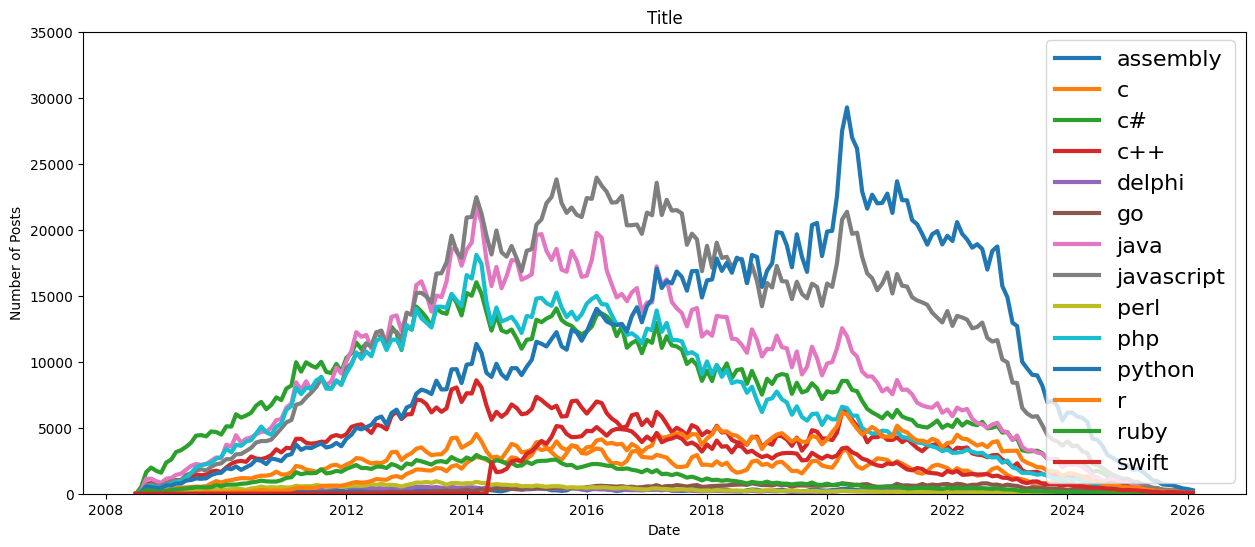

In [13]:
plt.figure(figsize=(15,6))
plt.title('Title')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.ylim(0, 35000)
for column in reshaped_df.columns:
    plt.plot(reshaped_df.index, reshaped_df[column],
             linewidth=3, label=reshaped_df[column].name)

plt.legend(fontsize=16)

plt.show()

# Smoothing out Time Series Data

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html). 

In [14]:
roll_df = reshaped_df.rolling(window=6).mean()

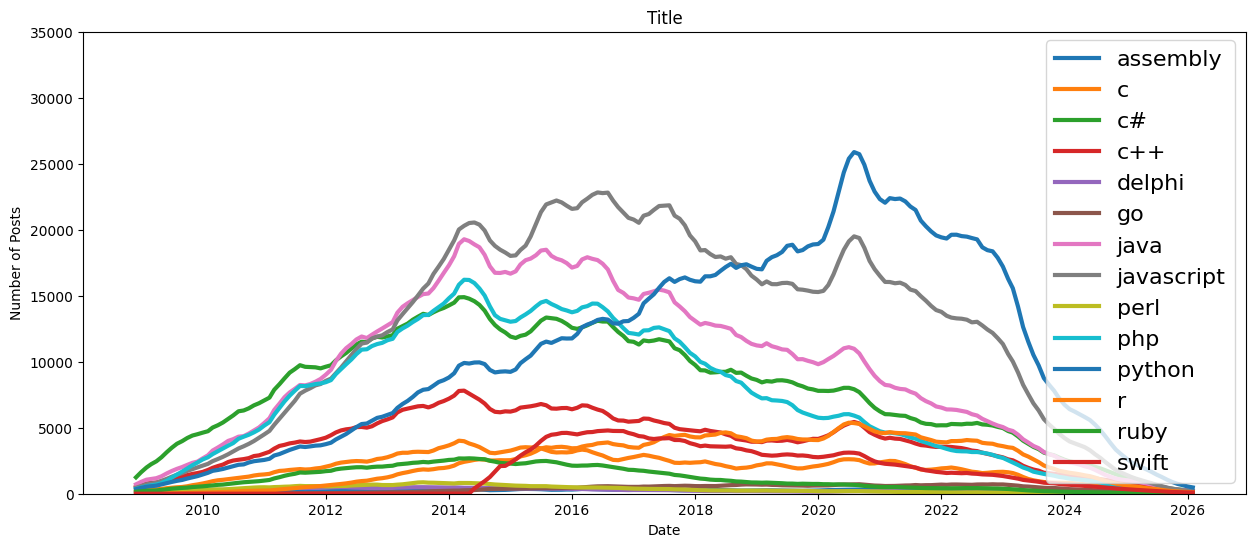

In [15]:
plt.figure(figsize=(15,6))
plt.title('Title')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.ylim(0, 35000)
for column in roll_df.columns:
    plt.plot(roll_df.index, roll_df[column],
             linewidth=3, label=roll_df[column].name)

plt.legend(fontsize=16)

plt.show()